# Resampling
Diego Dueñas Martín

# Conceptual

### 2. We will now derive the probability that a given observation is part of a bootstrap sample. Suppose that we obtain a bootstrap sample from a set of n observations.

#### (a) What is the probability that the first bootstrap observation is not the jth observation from the original sample? Justify your answer. 

Each bootstrap draw is made uniformly at random from the n original observations, and sampling is done with replacement.
Therefore, the probability of selecting the jth observation is  

$$P(j) = \frac{1}{n}$$

So, the probability of not selecting the jth observation is the complement:

$$
P(\text{not } j) = 1 - \frac{1}{n}.
$$

#### (b) What is the probability that the second bootstrap observation is not the jth observation from the original sample?

Because bootstrap uses replacement, each observation is independent, meaning it would still be:

$$
P(\text{not } j) = 1 - \frac{1}{n}.
$$

#### (c) Argue that the probability that the jth observation is not in the bootstrap sample is (1 − 1/n)^n.

A bootstrap sample of size n contains nn independent draws.

On each draw, the probability of not selecting the jth observation is

$$
1 - \frac{1}{n}
$$

Since the draws are independent, the probability that the jth observation is never selected in any of the n draws is

$$
P = \left(1 - \frac{1}{n}\right)^n
$$

#### (d) When n = 5, what is the probability that the jth observation is in the bootstrap sample?

$$
P = 1 - (1 - \frac{1}{5})^5 = 0.6723
$$

#### (e) When n = 100, what is the probability that the jth observation is in the bootstrap sample?

$$
P = 1 - (1 - \frac{1}{100})^100 = 0.6339
$$

#### (f) When n = 10, 000, what is the probability that the jth observation is in the bootstrap sample?

$$
P = 1 - (1 - \frac{1}{10,000})^{10,000} = 0.6321
$$

#### (g) Create a plot that displays, for each integer value of n from 1 to 100, 000, the probability that the jth observation is in the bootstrap sample. Comment on what you observe.


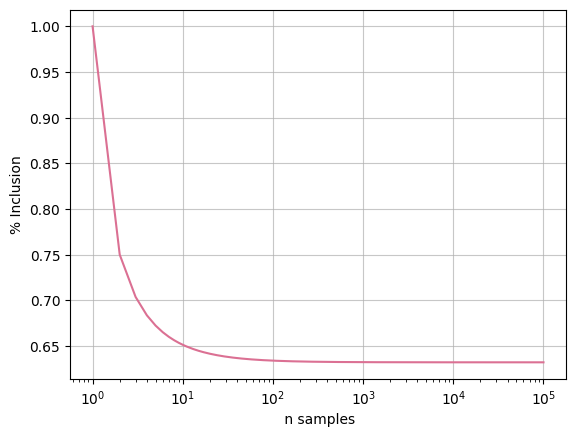

In [1]:
import numpy as np
import matplotlib.pyplot as plt

int_val = np.linspace(1, 100_000, 100_000, dtype=int)

def prob(n):

    prob_sample = 1 - ((n - 1) / n) ** n
    return prob_sample

probabilities = prob(int_val)

plt.plot(int_val, probabilities, color='palevioletred')
plt.grid( alpha=0.7)
plt.xlabel(' n samples')
plt.ylabel('% Inclusion')
plt.xscale('log')

#### (h) We will now investigate numerically the probability that a bootstrap sample of size n = 100 contains the jth observation. Here j = 4. We first create an array store with values that will subsequently be overwritten using the function np.empty(). We then repeatedly create bootstrap samples, and each time we record whether or not the fifth observation is contained in the bootstrap sample.

In [2]:
n = 100
j = 4
trials = 10000

store = np.empty(trials)

for t in range(trials):
    sample = np.random.choice(np.arange(n), size=n, replace=True)
    store[t] = (j in sample)

store.mean()

np.float64(0.6359)

In [3]:
rng = np.random.default_rng(10)
store = np.empty(10000)

for i in range(10000):
    store[i] = (np.sum(rng.choice(100, size=100, replace=True) == 4) > 0)

np.mean(store)

np.float64(0.6362)

The first code is the one I made, the second one, the one given by the book. In both cases, the mean from the stored results give a value close to the one that is shown in the plot before, the value that the probabilities start to converge to.

### 3. We now review k-fold cross-validation.
#### (a) Explain how k-fold cross-validation is implemented.

The dataset is split into k equally sized subsets. For each iteration, one subset is set aside as the test set, while the remaining k–1 subsets are combined to form the training set. The model is trained and evaluated k times, each time with a different test set. Finally, the performance results are averaged, giving a more reliable estimate of how the model generalizes.

#### (b) What are the advantages and disadvantages of k-fold cross-validation relative to:
##### i. The validation set approach?

Advantages:

Produces a more stable estimate of test error since it averages results across multiple splits.

Makes better use of the data, as most observations are used for training in each iteration.

Disadvantages:

Requires fitting the model multiple times, which increases computational cost compared to a single validation split.

##### ii. LOOCV?

Advantages:

Much faster, since the model is trained only k times instead of once per observation.

Typically has lower variance, because LOOCV training sets differ by just one point, which can make results unstable.

Disadvantages:

Slightly less precise in estimating test error, as each model is trained on fewer observations than in LOOCV.

LOOCV uses nearly the entire dataset for training each time, which can provide a closer reflection of performance on the full dataset.

### 4. Suppose that we use some statistical learning method to make a prediction for the response Y for a particular value of the predictor X.
Carefully describe how we might estimate the standard deviation of
our prediction.

To estimate prediction uncertainty, we use the bootstrap. The method repeatedly resamples the original data with replacement to create many bootstrap samples. For each sample, the model is refit and a prediction is made at the point of interest. The variation across these predictions shows how sensitive the model is to changes in the data. Measuring their spread gives an estimate of the prediction’s standard deviation. In short, by refitting on resampled datasets, we capture how much predictions fluctuate, providing a practical measure of uncertainty.

# Applied

### Problem 5

In [72]:

import pandas as pd
from sklearn.utils import resample
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from ISLP import load_data

a) Fit a logistic regression model that uses income and balance to
predict default.

In [54]:
def train_test_model(data, test_fraction=0.3, seed=None):
    data_split = train_test_split(data, test_size=test_fraction, random_state=seed)
    training, testing = data_split
    features_train = training.drop(columns=["default"])
    target_train = training["default"]
    features_test = testing.drop(columns=["default"])
    target_test = testing["default"]
    logit_model = sm.Logit(target_train, sm.add_constant(features_train)).fit()
    return logit_model, features_test, target_test

default = load_data('Default')
default["default"] = (default["default"] == "Yes").astype(int)
default = default.drop(columns=["student"])
x = default.drop(columns=["default"])
y = default["default"]
model_initial = sm.Logit(y, sm.add_constant(x)).fit()
model_initial.summary()

Optimization terminated successfully.
         Current function value: 0.078948
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9997
Method:                           MLE   Df Model:                            2
Date:                Tue, 05 May 2026   Pseudo R-squ.:                  0.4594
Time:                        19:22:55   Log-Likelihood:                -789.48
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                4.541e-292
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.5405      0.435    -26.544      0.000     -12.393     -10.688
balance        0.0056      0.000     24.835      0.000       0.005       0.006
income      2.081e-05   4.99e-06      4.174      0.000     1.1e-05    3.06e-05
==============================================================================

Possibly complete quasi-separation: A fraction 0.14 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

b)  Using the validation set approach, estimate the test error of this
model. In order to do this, you must perform the following steps:  
i. Split the sample set into a training set and a validation set.  
ii. Fit a multiple logistic regression model using only the training observations.  
iii. Obtain a prediction of default status for each individual in
the validation set by computing the posterior probability of
default for that individual, and classifying the individual to
the default category if the posterior probability is greater
than 0.5.  
iv. Compute the validation set error, which is the fraction of
the observations in the validation set that are misclassified.  

In [55]:
model_default, x_test, y_test = train_test_model(default, seed=42)
model_default.summary()

Optimization terminated successfully.
         Current function value: 0.078256
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6997
Method:                           MLE   Df Model:                            2
Date:                Tue, 05 May 2026   Pseudo R-squ.:                  0.4743
Time:                        19:22:58   Log-Likelihood:                -547.79
converged:                       True   LL-Null:                       -1042.0
Covariance Type:            nonrobust   LLR p-value:                2.273e-215
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.6019      0.522    -22.236      0.000     -12.624     -10.579
balance        0.0057      0.000     20.976      0.000       0.005       0.006
income      1.872e-05   5.92e-06      3.163      0.002    7.12e-06    3.03e-05
==============================================================================

Possibly complete quasi-separation: A fraction 0.15 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [48]:
predictions = model_default.predict(sm.add_constant(x_test))
classifications = (predictions >= 0.5).astype(int)
error_rate = np.mean(classifications != y_test)
error_rate

np.float64(0.02666666666666667)

c)  Repeat the process in (b) three times, using three different splits
of the observations into a training set and a validation set. Comment on the results obtained.

In [49]:
model_default, x_test, y_test = train_test_model(default, seed=10)
predictions = model_default.predict(sm.add_constant(x_test))
classifications = (predictions >= 0.5).astype(int)
error_rate = np.mean(classifications != y_test)
error_rate

Optimization terminated successfully.
         Current function value: 0.074116
         Iterations 10


np.float64(0.029666666666666668)

In [50]:
model_default, x_test, y_test = train_test_model(default, seed=5)
predictions = model_default.predict(sm.add_constant(x_test))
classifications = (predictions >= 0.5).astype(int)
error_rate = np.mean(classifications != y_test)
error_rate

Optimization terminated successfully.
         Current function value: 0.080827
         Iterations 10


np.float64(0.025)

In [51]:
model_default, x_test, y_test = train_test_model(default, seed=123)
predictions = model_default.predict(sm.add_constant(x_test))
classifications = (predictions >= 0.5).astype(int)
error_rate = np.mean(classifications != y_test)
error_rate

Optimization terminated successfully.
         Current function value: 0.081061
         Iterations 10


np.float64(0.025666666666666667)

d)  Now consider a logistic regression model that predicts the probability of default using income, balance, and a dummy variable
for student. Estimate the test error for this model using the validation set approach. Comment on whether or not including a
dummy variable for student leads to a reduction in the test error
rate.

In [53]:
default = load_data('Default')
default["default"] = (default["default"] == "Yes").astype(int)
default["student"] = (default["student"] == "Yes").astype(int)

model_default, x_test, y_test = train_test_model(default, seed=42)
model_default.summary()

Optimization terminated successfully.
         Current function value: 0.078031
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6996
Method:                           MLE   Df Model:                            3
Date:                Tue, 05 May 2026   Pseudo R-squ.:                  0.4758
Time:                        19:22:46   Log-Likelihood:                -546.22
converged:                       True   LL-Null:                       -1042.0
Covariance Type:            nonrobust   LLR p-value:                1.189e-214
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.0709      0.595    -18.620      0.000     -12.236      -9.906
student       -0.5051      0.284     -1.780      0.075      -1.061       0.051
balance        0.0058      0.000     20.872      0.000       0.005       0.006
income      4.794e-06   9.83e-06      0.488      0.626   -1.45e-05    2.41e-05
==============================================================================

Possibly complete quasi-separation: A fraction 0.15 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [ ]:
predictions = model_default.predict(sm.add_constant(x_test))
classifications = (predictions >= 0.5).astype(int)
error_rate = np.mean(classifications != y_test)
error_rate

np.float64(0.02666666666666667)

#### Commentary on results

Including the dummy variable did not improve the model for this train-test split, as the validation error stayed at 0.0267. Moreover, its p-value is 0.075, which exceeds the 0.05 threshold, meaning there is no statistically significant evidence that the variable affects the target.

### Problem 6  
We continue to consider the use of a logistic regression model to
predict the probability of default using income and balance on the
Default data set. In particular, we will now compute estimates for the
standard errors of the income and balance logistic regression coefficients in two different ways:  (1) using the bootstrap, and (2) using the
standard formula for computing the standard errors in the sm.GLM()
function. Do not forget to set a random seed before beginning your
analysis.

a) Using the summarize() and sm.GLM() functions, determine the
estimated standard errors for the coefficients associated with
income and balance in a multiple logistic regression model that
uses both predictors.

In [14]:
rng = np.random.default_rng(10) 

In [15]:
model_logit = model_initial
model_logit.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9997
Method:                           MLE   Df Model:                            2
Date:                Tue, 05 May 2026   Pseudo R-squ.:                  0.4594
Time:                        19:08:02   Log-Likelihood:                -789.48
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                4.541e-292
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.5405      0.435    -26.544      0.000     -12.393     -10.688
balance        0.0056      0.000     24.835      0.000       0.005       0.006
income      2.081e-05   4.99e-06      4.174      0.000     1.1e-05    3.06e-05
==============================================================================

Possibly complete quasi-separation: A fraction 0.14 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [16]:
se_income = model_logit.bse["income"]
se_balance = model_logit.bse["balance"]
se_income, se_balance

(np.float64(4.985245461753056e-06), np.float64(0.00022738138476844955))

In [17]:
model_glm = sm.GLM(y, sm.add_constant(x), family=sm.families.Binomial()).fit()
model_glm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                default   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9997
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -789.48
Date:                Tue, 05 May 2026   Deviance:                       1579.0
Time:                        19:08:02   Pearson chi2:                 6.95e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1256
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.5405      0.435    -26.544      0.000     -12.393     -10.688
balance        0.0056      0.000     24.835      0.000       0.005       0.006
income      2.081e-05   4.99e-06      4.174      0.000     1.1e-05    3.06e-05
==============================================================================
"""

In [18]:
se_income = model_glm.bse["income"]
se_balance = model_glm.bse["balance"]

se_income, se_balance

(np.float64(4.9852454582572105e-06), np.float64(0.0002273813844021005))

b)  Write a function, boot_fn(), that takes as input the Default data
set as well as an index of the observations, and that outputs
the coefficient estimates for income and balance in the multiple
logistic regression model.

In [19]:
import warnings
def boot_fn(data, index):
    sample = data.iloc[index, :]

    X_boot = sm.add_constant(sample[["income", "balance"]])
    y_boot = (sample["default"] == "Yes").astype(int)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        model = sm.GLM(
            y_boot,
            X_boot,
            family=sm.families.Binomial()
        ).fit()

    return model.params[["income", "balance"]]

c) Following the bootstrap example in the lab, use your boot_fn()
function to estimate the standard errors of the logistic regression
coefficients for income and balance.

In [56]:
def extract_coefs_from_bootstrap(dataset, n_iter=1000):
    coefficients = []
    for _ in range(n_iter):
        resampled = resample(dataset, replace=True, n_samples=len(dataset))
        features = sm.add_constant(resampled.drop(columns=["default"]))
        target = resampled["default"]
        try:
            model = sm.Logit(target, features).fit(disp=0)
            coefs = model.params[["income", "balance"]]
            coefficients.append(coefs.values)
        except:
            pass
    return np.array(coefficients)

bootstrap_coefs = extract_coefs_from_bootstrap(default, n_iter=1000)
se_income, se_balance = bootstrap_coefs.std(axis=0)
se_income, se_balance

(np.float64(4.563479074809586e-06), np.float64(0.00023334540311819373))

In [ ]:
def glm_bootstrap_coefs(data, n_bootstraps=1000):
    coefs_glm = []
    coefs_custom = []
    n_obs = len(data)
    
    for iteration in range(n_bootstraps):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            indices = np.random.choice(n_obs, n_obs, replace=True)
            
            X_features = data[["income", "balance"]].iloc[indices, :]
            y_target = (data["default"] == "Yes").astype(int).iloc[indices]
            X_with_const = sm.add_constant(X_features)
            
            glm_model = sm.GLM(y_target, X_with_const, family=sm.families.Binomial()).fit()
            coefs_glm.append(glm_model.params[["income", "balance"]].values)
            
            custom_coef = boot_fn(data, indices)
            if custom_coef is not None:
                coefs_custom.append(custom_coef.values)
    
    coefs_glm_array = np.array(coefs_glm)
    coefs_custom_array = np.array(coefs_custom)
    return coefs_glm_array.std(axis=0), coefs_custom_array.std(axis=0)

default = load_data('Default')
se_bi, se_bb = glm_bootstrap_coefs(default, n_bootstraps=1000)
bootstrap_coefs = extract_coefs_from_bootstrap(default, n_iter=1000)
se_income, se_balance = bootstrap_coefs.std(axis=0)
se_income, se_balance, se_bi, se_bb

(np.float64(4.853638510630876e-06),
 np.float64(0.00022992283721418922),
 np.float64(4.853638510630876e-06),
 np.float64(0.00022992283721418922))

d) Comment on the estimated standard errors obtained using the
sm.GLM() function and using the bootstrap.  

#### Commentary on results  
After bootstrapping, the standard errors shifted from 4.9852×10^−6 and 0.0002274 to 8.3493×10^−6 and 0.000228. While the differences are small, the bootstrap errors are slightly larger, suggesting that the original estimates may underestimate variability. This highlights bootstrap as a more robust way to capture uncertainty in the model parameters.

### Problem 7
In Sections 5.1.2 and 5.1.3, we saw that the cross_validate() function
can be used in order to compute the LOOCV test error estimate.
Alternatively, one could compute those quantities using just sm.GLM()
and the predict() method of the fitted model within a for loop. You
will now take this approach in order to compute the LOOCV error
for a simple logistic regression model on the Weekly data set. Recall
that in the context of classification problems, the LOOCV error is
given in (5.4).

a) Fit a logistic regression model that predicts Direction using Lag1
and Lag2.

In [22]:
from ISLP import load_data
weekly = load_data("Weekly")
weekly['Direction'] = (weekly['Direction'] == 'Up').astype(int)
x = weekly[['Lag1', 'Lag2']]
y = weekly['Direction']

In [23]:
model_weekly = sm.Logit(y, sm.add_constant(x)).fit()
model_weekly.summary()

Optimization terminated successfully.
         Current function value: 0.683297
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              Direction   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1086
Method:                           MLE   Df Model:                            2
Date:                Tue, 05 May 2026   Pseudo R-squ.:                0.005335
Time:                        19:09:18   Log-Likelihood:                -744.11
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                   0.01848
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2212      0.061      3.599      0.000       0.101       0.342
Lag1          -0.0387      0.026     -1.477      0.140      -0.090       0.013
Lag2           0.0602      0.027      2.270      0.023       0.008       0.112
==============================================================================
"""

b) Fit a logistic regression model that predicts Direction using Lag1
and Lag2 using all but the first observation

In [ ]:
def remove_first_observation(features, target):
    return features.iloc[1:], target.iloc[1:]

x_wo_first, y_wo_first = remove_first_observation(x, y)
model_weekly_wo_first = sm.Logit(y_wo_first, sm.add_constant(x_wo_first)).fit()

model_weekly_wo_first.summary()

Optimization terminated successfully.
         Current function value: 0.683147
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              Direction   No. Observations:                 1088
Model:                          Logit   Df Residuals:                     1085
Method:                           MLE   Df Model:                            2
Date:                Tue, 05 May 2026   Pseudo R-squ.:                0.005387
Time:                        19:09:18   Log-Likelihood:                -743.26
converged:                       True   LL-Null:                       -747.29
Covariance Type:            nonrobust   LLR p-value:                   0.01785
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2232      0.061      3.630      0.000       0.103       0.344
Lag1          -0.0384      0.026     -1.466      0.143      -0.090       0.013
Lag2           0.0608      0.027      2.291      0.022       0.009       0.113
==============================================================================
"""

c) Use the model from (b) to predict the direction of the first observation. You can do this by predicting that the first observation
will go up if P(Direction = "Up"|Lag1, Lag2) > 0.5. Was this
observation correctly classified?

In [ ]:
x_first = x.iloc[[0]]
y_first = y.iloc[[0]]
x_first_const = sm.add_constant(x_first, has_constant='add')

pred_prob_first = model_weekly_wo_first.predict(x_first_const)
classif_first = (pred_prob_first >= 0.5).astype(int)

print(f"Predicted probability for first value: {pred_prob_first.values[0]}")
print(f"Predicted class for first value: {classif_first.values[0]}")
print(f"Real class for first value: {y_first.values[0]}")
print(f"Is it correct? {classif_first.values[0] == y_first.values[0]}")

Predicted probability for first value: 0.5713923205204433
Predicted class for first value: 1
Real class for first value: 0
Is it correct? False


d) Write a for loop from i = 1 to i = n, where n is the number of
observations in the data set, that performs each of the following
steps:  
  
i. Fit a logistic regression model using all but the ith observation to predict Direction using Lag1 and Lag2.  
ii. Compute the posterior probability of the market moving up
for the ith observation.  
iii. Use the posterior probability for the ith observation in order
to predict whether or not the market moves up.  
iv. Determine whether or not an error was made in predicting
the direction for the ith observation. If an error was made 
then indicate this as a 1, and otherwise indicate it as a 0.  

In [ ]:
def loocv_error_computation(features, target):
    n_samples = len(features)
    misclassifications = np.zeros(n_samples)
    
    for idx in range(n_samples):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            X_train = sm.add_constant(features.drop(idx), has_constant='add')
            y_train = target.drop(idx)
            X_test = sm.add_constant(features.iloc[idx:idx+1], has_constant='add')
            y_test = target.iloc[idx]
            
            fitted_model = sm.Logit(y_train, X_train).fit(disp=0)
            probability = fitted_model.predict(X_test)
            prediction = probability >= 0.5
            
            misclassifications[idx] = int(prediction != y_test)
    
    return misclassifications

errors = loocv_error_computation(x, y)

e) Take the average of the n numbers obtained in (d)iv in order to
obtain the LOOCV estimate for the test error. Comment on the
results.

In [27]:
loocv_error = errors.mean()
loocv_error

np.float64(0.44995408631772266)

#### Commentary on results

The LOOCV error was 0.44995, which indicates that the model misclassified approximately 45% of the observations when each data point was left out and used as a test case. This relatively high error suggests that the model's predictive performance is limited, and it may struggle to generalize to new data. The LOOCV process provides a nearly unbiased estimate of the model’s true error since each observation is used once as a test case.

### Problem 8  
We will now perform cross-validation on a simulated data set

a)  Generate a simulated data set as follows:  
rng = np.random.default_rng(1)  
x = rng.normal(size=100)  
y = x - 2 * x**2 + rng.normal(size=100)   
In this data set, what is n and what is p? Write out the model
used to generate the data in equation form

In [ ]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

# n = observaciones
# p = número de predictores
# n = 100
# p = 1

b)  Create a scatterplot of X against Y . Comment on what you find.

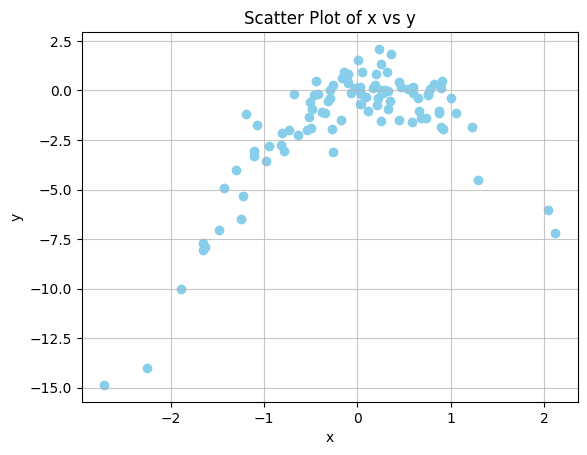

In [61]:
plt.scatter(x, y, color='skyblue')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot of x vs y')
plt.grid(alpha=0.7)

c)  Set a random seed, and then compute the LOOCV errors that
result from fitting the following four models using least squares:  
i. Y = β0 + β1X + "  
ii. Y = β0 + β1X + β2X2 + "  
iii. Y = β0 + β1X + β2X2 + β3X3 + "  
iv. Y = β0 + β1X + β2X2 + β3X3 + β4X4 + ".  
Note you may find it helpful to use the data.frame() function
to create a single data set containing both X and Y .

In [62]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)
df = pd.DataFrame({"x": x, "y": y})

def polynomial_loocv_error(dataframe, polynomial_degree):
    dataset_size = len(dataframe)
    squared_errors = []
    
    for leave_out_idx in range(dataset_size):
        train_set = dataframe.drop(leave_out_idx)
        test_set = dataframe.iloc[leave_out_idx]
        
        train_features = np.column_stack([train_set["x"]**p for p in range(1, polynomial_degree+1)])
        train_features = np.column_stack([np.ones(len(train_set)), train_features])
        
        test_features = np.array([test_set["x"]**p for p in range(1, polynomial_degree+1)]).reshape(1, -1)
        test_features = np.column_stack([1, test_features])
        
        ols_model = sm.OLS(train_set["y"], train_features).fit()
        predicted = ols_model.predict(test_features)[0]
        squared_errors.append((test_set["y"] - predicted)**2)
    
    return np.mean(squared_errors)

loocv_results = [polynomial_loocv_error(df, d) for d in range(1, 5)]
loocv_deg1, loocv_deg2, loocv_deg3, loocv_deg4 = loocv_results
loocv_deg1, loocv_deg2, loocv_deg3, loocv_deg4

(np.float64(6.633029839181983),
 np.float64(1.1229368563419688),
 np.float64(1.3017965489358907),
 np.float64(1.3323942694179332))

d) Repeat (c) using another random seed, and report your results.
Are your results the same as what you got in (c)? Why?

In [ ]:
rng = np.random.default_rng(42)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)
df = pd.DataFrame({"x": x, "y": y})

loocv_results_2 = [polynomial_loocv_error(df, d) for d in range(1, 5)]
loocv_deg1, loocv_deg2, loocv_deg3, loocv_deg4 = loocv_results_2
loocv_deg1, loocv_deg2, loocv_deg3, loocv_deg4

(np.float64(4.2518828656027745),
 np.float64(0.9639984632709351),
 np.float64(0.9912711879229293),
 np.float64(1.0181801043809104))

e) Which of the models in (c) had the smallest LOOCV error? Is
this what you expected? Explain your answer.

The smallest LOOCV error was the one from degree 2.

f)  Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using
least squares. Do these results agree with the conclusions drawn
based on the cross-validation results?

Across all four models, the significance tests aligned with the cross-validation results. In the linear model, the single predictor appeared important but failed to capture the full relationship. In the quadratic model, both predictors were highly significant, consistent with the curved data-generating process. In contrast, the cubic and quartic models added terms that were not significant and did not improve the fit, mostly introducing noise. This matches the cross-validation outcome, which identified the quadratic model as the best performer, while more complex models offered no real benefit.


### Problem 9  
We will now consider the Boston housing data set, from the ISLP
library.

a)  Based on this data set, provide an estimate for the population
mean of medv. Call this estimate µˆ.

In [63]:
boston = pd.read_excel("Boston Housing Dataset 1978.xlsx")
mu_hat = boston["MEDV"].mean()
mu_hat

np.float64(23.750442477876106)

b)  Provide an estimate of the standard error of µˆ. Interpret this
result.

In [64]:
standard_error = boston["MEDV"].std(ddof=1) / np.sqrt(len(boston))
standard_error

np.float64(0.39159010800148075)

c) Now estimate the standard error of µˆ using the bootstrap. How
does this compare to your answer from (b)?

In [65]:
def bootstrap_mean_estimates(dataset, column, n_bootstraps=1000):
    estimates = []
    for _ in range(n_bootstraps):
        resampled = resample(dataset, replace=True, n_samples=len(dataset))
        estimates.append(resampled[column].mean())
    return np.array(estimates)

mu_bootstrap = bootstrap_mean_estimates(boston, "MEDV", n_bootstraps=1000)

In [66]:
bootstrap_se = mu_bootstrap.std(ddof=1)
print(f"Bootstrap standard error: {bootstrap_se}")
bootstrap_se

Bootstrap standard error: 0.42136912756822836


np.float64(0.42136912756822836)

d)  Based on your bootstrap estimate from (c), provide a 95 % confidence interval for the mean of medv. Compare it to the results
obtained by using Boston['medv'].std() and the two standard
error rule (3.9).

In [67]:
mu_hat = boston["MEDV"].mean()
ci_lower = mu_hat - 2 * bootstrap_se
ci_upper = mu_hat + 2 * bootstrap_se
ci_lower, ci_upper

(np.float64(22.90770422273965), np.float64(24.593180733012563))

e) Based on this data set, provide an estimate, µˆmed, for the median
value of medv in the population.

In [68]:
mu_hat_med = boston["MEDV"].median()
mu_hat_med

np.float64(21.95)

f) We now would like to estimate the standard error of µˆmed. Unfortunately, there is no simple formula for computing the standard
error of the median. Instead, estimate the standard error of the
median using the bootstrap. Comment on your findings

In [69]:
def bootstrap_median_estimates(dataset, column, n_bootstraps=1000):
    estimates = []
    for _ in range(n_bootstraps):
        resampled = resample(dataset, replace=True, n_samples=len(dataset))
        estimates.append(resampled[column].median())
    return np.array(estimates)

median_bootstrap = bootstrap_median_estimates(boston, "MEDV", n_bootstraps=1000)
median_bootstrap_se = median_bootstrap.std(ddof=1)
median_bootstrap_se

np.float64(0.31207606279394307)

g)  Based on this data set, provide an estimate for the tenth percentile of medv in Boston census tracts. Call this quantity µˆ0.1.
(You can use the np.percentile() function.)

In [70]:
mu_hat_0_1 = np.percentile(boston["MEDV"].dropna(), 10)
mu_hat_0_1

np.float64(14.5)

h)  Use the bootstrap to estimate the standard error of µˆ0.1. Comment on your findings.

In [71]:
def bootstrap_percentile_estimates(dataset, column, percentile, n_bootstraps=1000):
    estimates = []
    for _ in range(n_bootstraps):
        resampled = resample(dataset, replace=True, n_samples=len(dataset))
        estimates.append(np.percentile(resampled[column].dropna(), percentile))
    return np.array(estimates)

percentile_bootstrap = bootstrap_percentile_estimates(boston, "MEDV", 10, n_bootstraps=1000)
percentile_bootstrap_se = percentile_bootstrap.std(ddof=1)
percentile_bootstrap_se

np.float64(0.40265896568019277)